# Week 3 — ARMA Models

Autoregressive Moving Average (ARMA) models are the building blocks of time-series forecasting. This notebook covers AR, MA, and ARMA processes, their properties, and how to identify them from data.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 3.1 The AR(1) Process

$$y_t = c + \phi y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim WN(0, \sigma^2)$$

Stationarity requires $|\phi| < 1$.

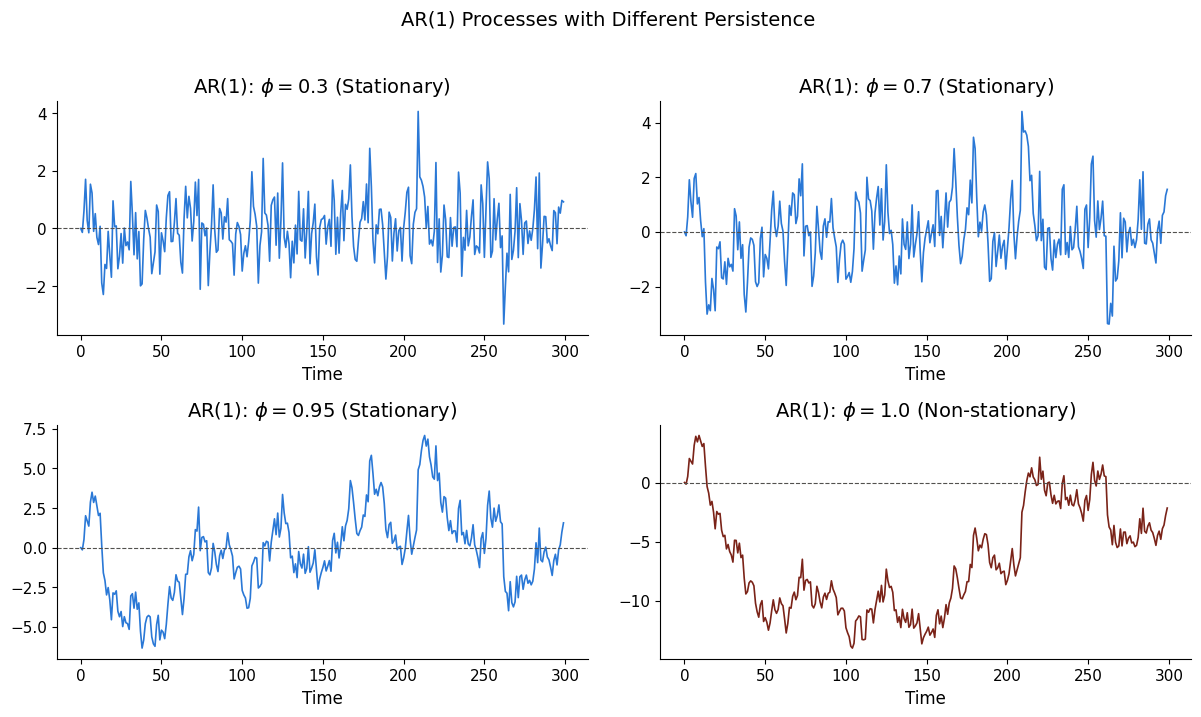

In [2]:
np.random.seed(42)
T = 300
eps = np.random.normal(0, 1, T)

phi_values = [0.3, 0.7, 0.95, 1.0]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, phi in zip(axes.flat, phi_values):
    y = np.zeros(T)
    for t in range(1, T):
        y[t] = phi * y[t-1] + eps[t]
    ax.plot(y, color=UOE_RED if phi >= 1 else UOE_BLUE, lw=1.2)
    ax.axhline(0, ls='--', color=UOE_GREY, lw=0.8)
    status = 'Non-stationary' if phi >= 1 else 'Stationary'
    ax.set_title(f'AR(1): $\\phi = {phi}$ ({status})')
    ax.set_xlabel('Time')

plt.suptitle('AR(1) Processes with Different Persistence', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 3.2 The MA(1) Process

$$y_t = \mu + \varepsilon_t + \theta \varepsilon_{t-1}$$

MA processes are always stationary. The ACF cuts off after lag $q$.

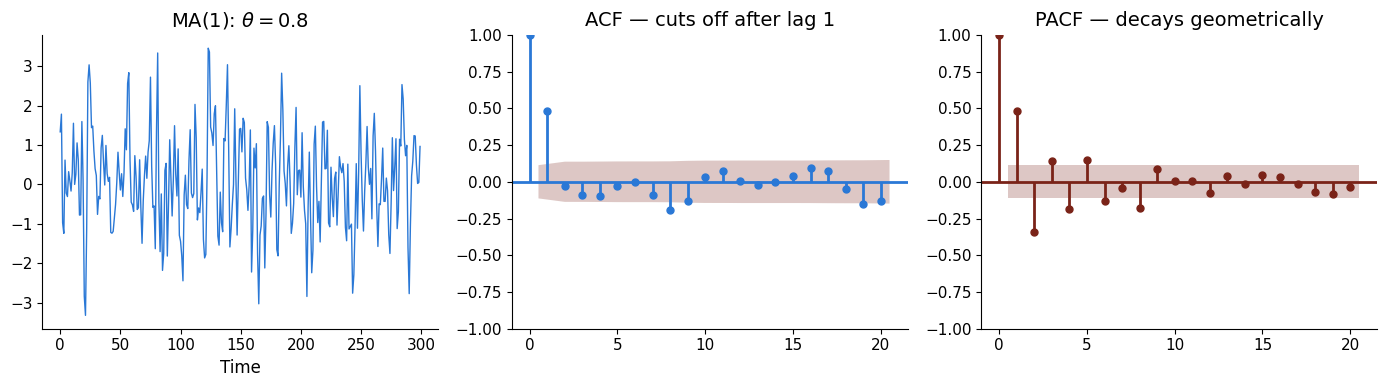

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess

# MA(1) with theta = 0.8
ma1 = ArmaProcess(ar=[1], ma=[1, 0.8])
np.random.seed(10)
y_ma = ma1.generate_sample(nsample=300)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
ax1.plot(y_ma, color=UOE_BLUE, lw=1)
ax1.set_title('MA(1): $\\theta = 0.8$')
ax1.set_xlabel('Time')

plot_acf(y_ma, lags=20, ax=ax2, color=UOE_BLUE, vlines_kwargs={'color': UOE_BLUE})
ax2.set_title('ACF — cuts off after lag 1')

plot_pacf(y_ma, lags=20, ax=ax3, color=UOE_RED, vlines_kwargs={'color': UOE_RED})
ax3.set_title('PACF — decays geometrically')

plt.tight_layout()
plt.show()


## 3.3 ARMA(p, q) — Combining AR and MA

$$y_t = c + \sum_{i=1}^{p} \phi_i y_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}$$

**Identification rules:**

| Model | ACF | PACF |
|:------|:----|:-----|
| AR(p) | Decays | Cuts off after lag $p$ |
| MA(q) | Cuts off after lag $q$ | Decays |
| ARMA(p,q) | Decays | Decays |

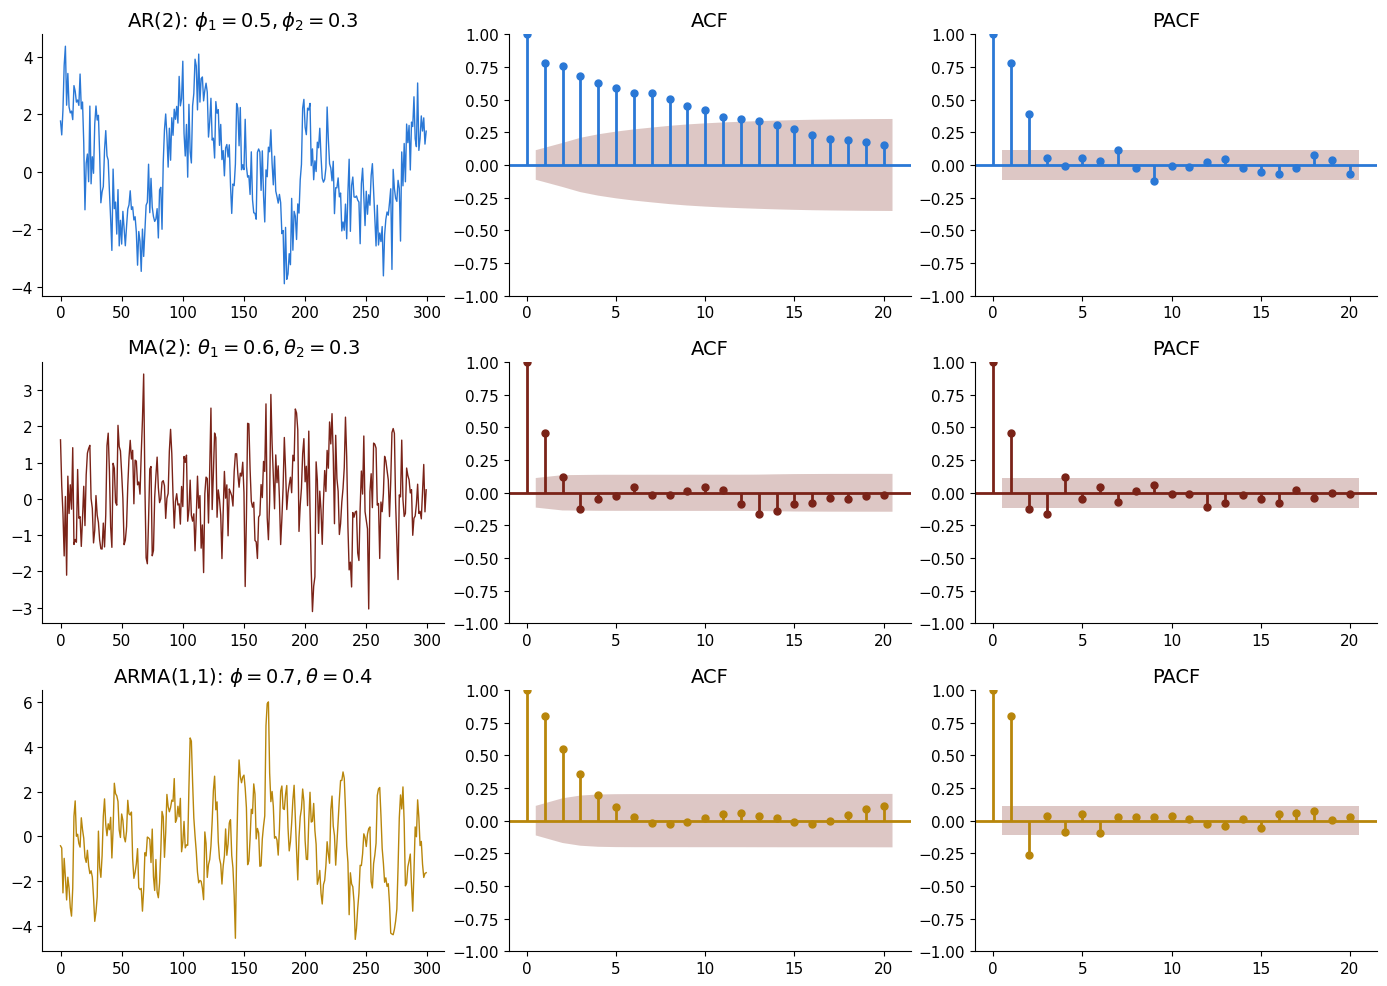

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Theoretical ACF/PACF for different ARMA models
from statsmodels.tsa.arima_process import ArmaProcess

models = {
    'AR(2): $\\phi_1=0.5, \\phi_2=0.3$': ArmaProcess(ar=[1, -0.5, -0.3], ma=[1]),
    'MA(2): $\\theta_1=0.6, \\theta_2=0.3$': ArmaProcess(ar=[1], ma=[1, 0.6, 0.3]),
    'ARMA(1,1): $\\phi=0.7, \\theta=0.4$': ArmaProcess(ar=[1, -0.7], ma=[1, 0.4]),
}

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
colours = [UOE_BLUE, UOE_RED, UOE_GOLD]

for row, ((name, proc), col) in enumerate(zip(models.items(), colours)):
    np.random.seed(row)
    y = proc.generate_sample(nsample=300)
    axes[row, 0].plot(y, color=col, lw=1)
    axes[row, 0].set_title(name)
    plot_acf(y, lags=20, ax=axes[row, 1], color=col, vlines_kwargs={'color': col})
    axes[row, 1].set_title('ACF')
    plot_pacf(y, lags=20, ax=axes[row, 2], color=col, vlines_kwargs={'color': col})
    axes[row, 2].set_title('PACF')

plt.tight_layout()
plt.show()


## 3.4 Variance of ARMA Processes

The unconditional variance of an AR(1) is $\sigma_y^2 = \sigma^2 / (1 - \phi^2)$, which increases sharply as $\phi \to 1$.

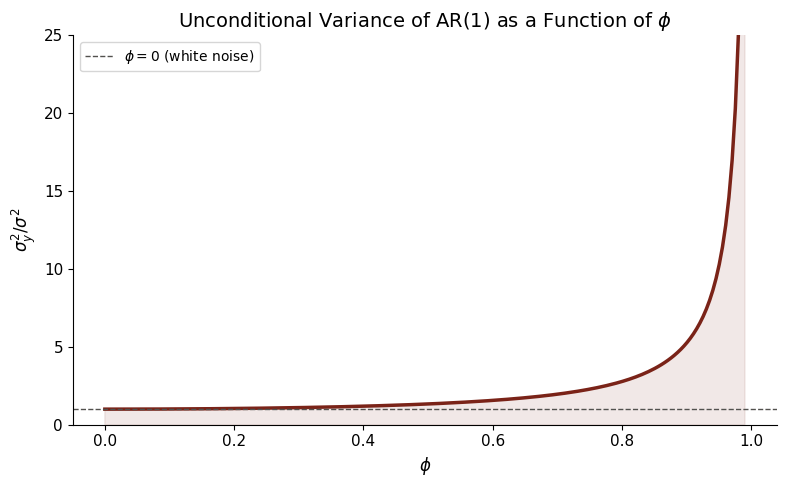

In [5]:
phi_grid = np.linspace(0, 0.99, 200)
variance = 1 / (1 - phi_grid**2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(phi_grid, variance, color=UOE_RED, lw=2.5)
ax.fill_between(phi_grid, variance, alpha=0.1, color=UOE_RED)
ax.set_xlabel('$\\phi$')
ax.set_ylabel('$\\sigma_y^2 / \\sigma^2$')
ax.set_title('Unconditional Variance of AR(1) as a Function of $\\phi$')
ax.set_ylim(0, 25)
ax.axhline(1, ls='--', color=UOE_GREY, lw=1, label='$\\phi = 0$ (white noise)')
ax.legend()
plt.tight_layout()
plt.show()


## Exercises

<details><summary>Exercise 1: Simulate an ARMA(2,1) and use ACF/PACF to identify the order.</summary>

```python
proc = ArmaProcess(ar=[1, -0.6, -0.2], ma=[1, 0.4])
y = proc.generate_sample(nsample=500)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, lags=25, ax=ax1)
plot_pacf(y, lags=25, ax=ax2)
plt.show()
# Both ACF and PACF decay → ARMA model
```
</details>